Project Part 2.2: Data Preparation and Preliminary Analysis Report - 05/26/2026 - aarsin4634

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from datetime import datetime
from IPython.display import display, Markdown

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "aarsin4634"

display(Markdown(f"### Project Part 2.2: Exploratory Data Analysis & Preprocessing - {todays_date} - {student_id}"))

# Load the dataset
df = pd.read_csv('train.csv')

display(Markdown("#### Initial Dataset Overview"))
print(f"Dataset Shape: {df.shape}")
display(df.head())

### Project Part 2.2: Exploratory Data Analysis & Preprocessing - 2026-05-26 - aarsin4634

#### Initial Dataset Overview

Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### Univariate Analysis

--- Summary Statistics for Key Features ---


,SalePrice,GrLivArea,TotalBsmtSF,YearBuilt,OverallQual
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,180921.195890,1515.463699,1057.429452,1971.267808,6.099315
std,79442.502883,525.480383,438.705324,30.202904,1.382997
min,34900.000000,334.000000,0.000000,1872.000000,1.000000
25%,129975.000000,1129.500000,795.750000,1954.000000,5.000000
50%,163000.000000,1464.000000,991.500000,1973.000000,6.000000
75%,214000.000000,1776.750000,1298.250000,2000.000000,7.000000
max,755000.000000,5642.000000,6110.000000,2010.000000,10.000000


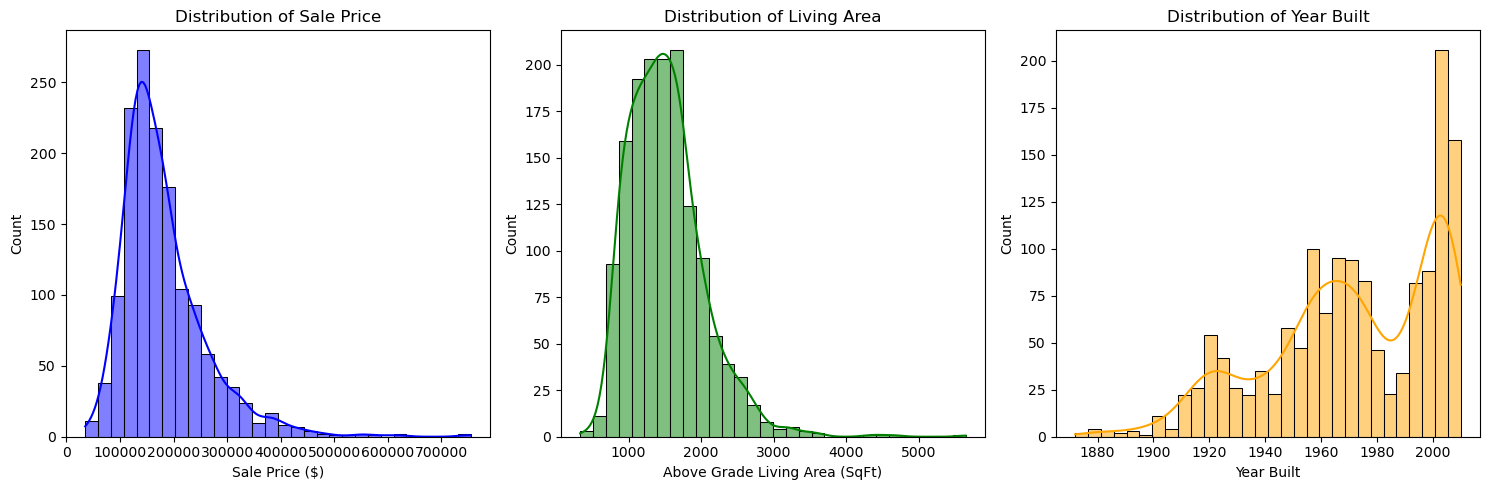

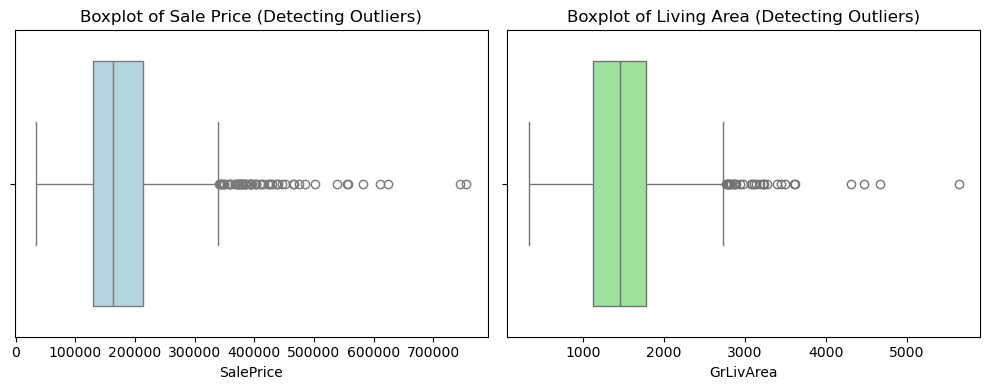

In [2]:
display(Markdown("#### Univariate Analysis"))

# Select a few key numerical features relevant to predicting house prices
key_features = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'OverallQual']

# Summary Statistics
print("--- Summary Statistics for Key Features ---")
display(df[key_features].describe())

# Histograms to visualize the distribution of numerical features
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['SalePrice'], kde=True, color='blue', bins=30)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')

plt.subplot(1, 3, 2)
sns.histplot(df['GrLivArea'], kde=True, color='green', bins=30)
plt.title('Distribution of Living Area')
plt.xlabel('Above Grade Living Area (SqFt)')

plt.subplot(1, 3, 3)
sns.histplot(df['YearBuilt'], kde=True, color='orange', bins=30)
plt.title('Distribution of Year Built')
plt.xlabel('Year Built')

plt.tight_layout()
plt.show()

# Box plots to detect outliers
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['SalePrice'], color='lightblue')
plt.title('Boxplot of Sale Price (Detecting Outliers)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['GrLivArea'], color='lightgreen')
plt.title('Boxplot of Living Area (Detecting Outliers)')

plt.tight_layout()
plt.show()

#### Bivariate and Multivariate Analysis

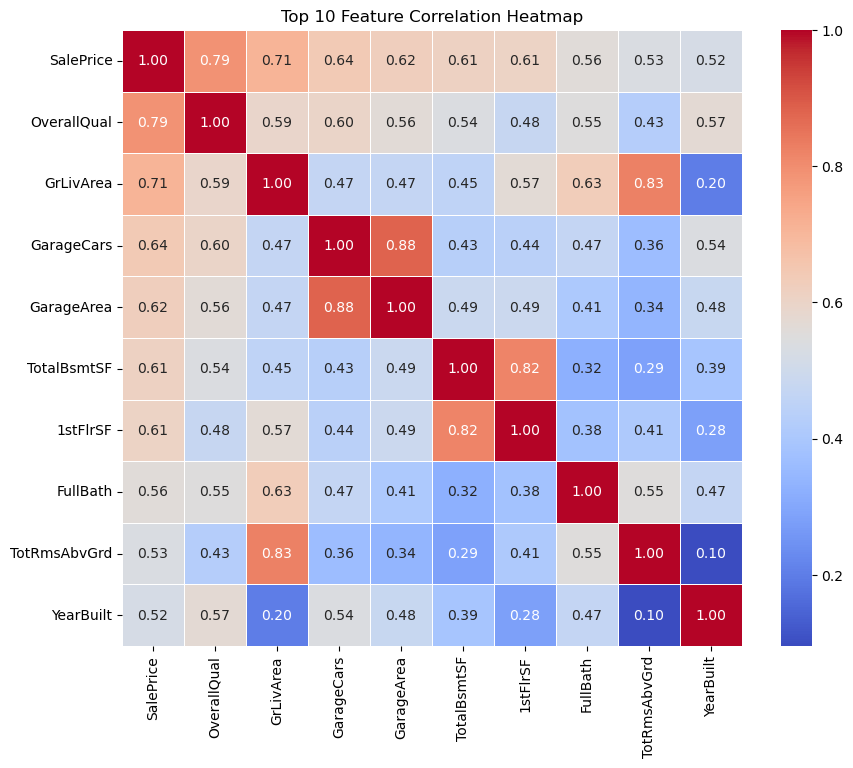

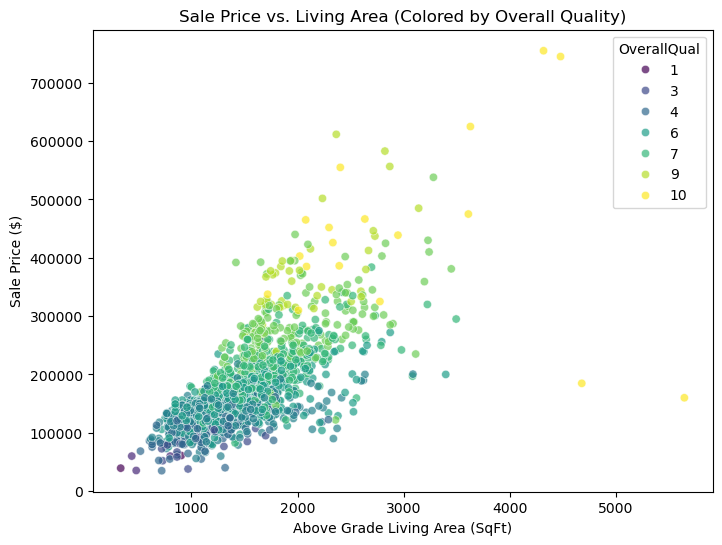

In [3]:
display(Markdown("#### Bivariate and Multivariate Analysis"))

# Correlation Matrix & Heatmap
# Filter only the numeric columns so the correlation math works
numeric_df = df.select_dtypes(include=[np.number])

# Find the top 10 features most correlated with SalePrice
top_corr_features = numeric_df.corr()['SalePrice'].sort_values(ascending=False).head(10).index
corr_matrix = numeric_df[top_corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Top 10 Feature Correlation Heatmap')
plt.show()

# Bivariate Scatter Plot
# Visualizing how Living Area affects Price, colored by the Overall Quality
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], hue=df['OverallQual'], palette='viridis', alpha=0.7)
plt.title('Sale Price vs. Living Area (Colored by Overall Quality)')
plt.xlabel('Above Grade Living Area (SqFt)')
plt.ylabel('Sale Price ($)')
plt.show()

In [4]:
display(Markdown("#### Data Preprocessing"))

# Create a copy of the dataframe so we don't alter the original raw data
df_clean = df.copy()

# --- Handle Missing Data ---
# Fill numerical missing values with the median
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())

# Fill categorical missing values representing 'None' (e.g., no pool, no fence)
cols_to_fill_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in cols_to_fill_none:
    df_clean[col] = df_clean[col].fillna('None')

# --- Basic Feature Engineering ---
# Combine square footage to make a simpler "Total Square Footage" column
df_clean['TotalSqFt'] = df_clean['GrLivArea'] + df_clean['TotalBsmtSF']

print("Missing values handled and basic feature engineering completed.")

#### Data Preprocessing

Missing values handled and basic feature engineering completed.
